In [8]:
import os
import sys

# Get the absolute path of the directory containing the notebook
notebook_dir = '/Volumes/rvmartin2/Active/yany1/1.project/DL_US_2019/code/Data_Processing/Get_OpenStreetMap_Input'
# Change the working directory to the notebook's location
os.chdir(notebook_dir)

# Add the current directory to Python path
sys.path.append(os.getcwd())

# Print current working directory and Python path for verification
print(f"Current working directory: {os.getcwd()}")
print(f"Python path: {sys.path}")
import numpy as np
import geopandas as gpd
import numpy as np
from OSM_pkg.iostream import *
import time
from scipy.interpolate import NearestNDInterpolator
from rasterio.transform import from_origin
import rasterio
from rasterio.features import rasterize
from shapely.geometry import box
from rasterio.transform import xy
from affine import Affine
import osmnx as ox

%matplotlib inline
import matplotlib.pyplot as plt

Current working directory: /Volumes/rvmartin2/Active/yany1/1.project/DL_US_2019/code/Data_Processing/Get_OpenStreetMap_Input
Python path: ['/Users/yanyu/miniconda3/envs/d2l/lib/python310.zip', '/Users/yanyu/miniconda3/envs/d2l/lib/python3.10', '/Users/yanyu/miniconda3/envs/d2l/lib/python3.10/lib-dynload', '', '/Users/yanyu/miniconda3/envs/d2l/lib/python3.10/site-packages', '/Volumes/rvmartin2/Active/yany1/1.project/DL_US_2019/code/Data_Processing/Get_OpenStreetMap_Input', '/Volumes/rvmartin2/Active/yany1/1.project/DL_US_2019/code/Data_Processing/Get_OpenStreetMap_Input']


In [2]:
road_colors = {
    'motorway': 'red',
    # 'motorway_link': 'darkred',
    'trunk': 'orange',
    # 'trunk_link': 'darkorange',
    'primary': 'black',
    # 'primary_link': 'gold',
    'secondary': 'green',
    # 'secondary_link': 'darkgreen',
    'tertiary': 'blue',
    # 'tertiary_link': 'darkblue',
    'residential': 'purple',
    'unclassified': 'gray',
    # 'service': 'lightgray',
    # 'track': 'brown',
    # 'path': 'pink',
    # 'cycleway': 'cyan',
    # 'footway': 'magenta',
    # 'steps': 'magenta',
    # 'pedestrian': 'magenta',
    # 'living_street': 'lightblue',
    # 'bridleway': 'lightgreen',
    # 'busway': 'yellow',
    # 'unknown': 'white'
}

In [35]:
indir = '/Volumes/rvmartin2/Active/yany1/1.project/OpenStreetMap/'
infile = indir + 'processed_p.shp'
init_shp_data = gpd.read_file(infile)

In [36]:
print("\nSHP Data Structure:")
print("Type:", type(init_shp_data))
print("Columns:", init_shp_data.columns.tolist())
print("Number of rows:", len(init_shp_data))
print("Geometry type:", init_shp_data.geometry.type.unique())
print("\nFirst few rows:")
print(init_shp_data.head())
print(init_shp_data.tail())
print(init_shp_data.shape)
print(init_shp_data['fclass'].unique())


SHP Data Structure:
Type: <class 'geopandas.geodataframe.GeoDataFrame'>
Columns: ['error', 'tile_x', 'tile_y', 'geometry']
Number of rows: 562302
Geometry type: ['Polygon']

First few rows:
   error  tile_x  tile_y                                           geometry
0      0       0       0  POLYGON ((-20037453.591 -19937170, -19937170 -...
1      0       0       1  POLYGON ((-20037461.949 -19836982, -19937170 -...
2      0       0       2  POLYGON ((-20017843.843 -19736796, -19937170 -...
3      0       0       3  POLYGON ((-20011312.465 -19636608, -19937170 -...
4      0       0       4  POLYGON ((-20004781.088 -19536420, -19937170 -...
        error  tile_x  tile_y  \
562297      0     399     315   
562298      0     399     315   
562299      0     399     315   
562300      0     399     315   
562301      0     399     315   

                                                 geometry  
562297  POLYGON ((20001320.157 11555848.16, 20001324.1...  
562298  POLYGON ((20004207.228 115

KeyError: 'fclass'

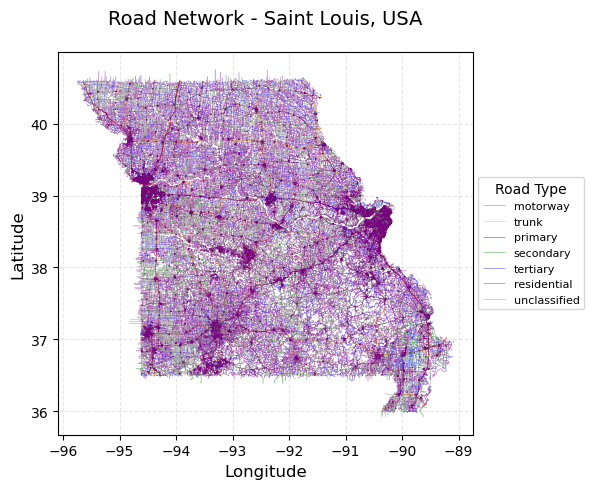

In [34]:
G = ox.graph_from_place("saint louis, USA", network_type="drive")
orig, dest = list(G.nodes())[0], list(G.nodes())[100]
route = ox.shortest_path(G, orig, dest)
fig, ax = plt.subplots(figsize=(10, 5))
plt.title("Road Network - Saint Louis, USA", fontsize=14, pad=20)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)  # Light grid lines
plt.tight_layout()  # Prevents label cutoff

for road_type in road_colors.keys():
    mask = init_shp_data['fclass'] == road_type
    if mask.any():
        init_shp_data[mask].plot(ax=ax, 
                           color=road_colors[road_type],
                           alpha=0.5,
                           linewidth=0.5,
                           label=road_type)
        
legend = ax.legend(title="Road Type", 
                  loc='center left', 
                  bbox_to_anchor=(1, 0.5),
                  fontsize=8,
                  title_fontsize=10)

In [10]:
def download_torrent(torrent_path, save_path):
    """
    Download a file from a torrent
    """
    # Create a session
    ses = lt.session()
    ses.listen_on(6881, 6891)
    
    # Add the torrent to the session
    info = lt.torrent_info(torrent_path)
    h = ses.add_torrent({'ti': info, 'save_path': save_path})
    
    # Wait for the download to complete
    while not h.is_seed():
        s = h.status()
        state_str = ['queued', 'checking', 'downloading metadata', 'downloading', 'finished', 'seeding', 'allocating']
        print(f'Downloading: {s.progress * 100:.1f}% complete (down: {s.download_rate / 1000:.1f} kB/s, up: {s.upload_rate / 1000:.1f} kB/s, peers: {s.num_peers})')
        time.sleep(1)

In [16]:
def load_road_osmfile(indir, YEAR):
    osm_file = None
    is_torrent = False
    
    if os.path.exists(indir + f'history-{YEAR}.osm.bz2'):
        osm_file = indir + f'history-{YEAR}.osm.bz2'
    elif os.path.exists(indir + f'history-{YEAR}.osm.bz2.torrent'):
        osm_file = indir + f'history-{YEAR}.osm.bz2.torrent'
        is_torrent = True
    
    if not osm_file:
        raise FileNotFoundError(f"No OSM file found for year {YEAR}")
    
    # Create a temporary directory for processing
    with tempfile.TemporaryDirectory() as temp_dir:
        # Handle the file based on its type
        if is_torrent:
            print(f"Downloading torrent file for {YEAR}...")
            osm_file = download_torrent(osm_file, temp_dir)
        
        # Extract the bz2 file
        temp_osm = os.path.join(temp_dir, f'history-{YEAR}.osm')
        with bz2.open(osm_file, 'rt') as source, open(temp_osm, 'w') as target:
            shutil.copyfileobj(source, target)
        
        # Process the OSM file using osmium
        class RoadHandler(osmium.SimpleHandler):
            def __init__(self):
                super(RoadHandler, self).__init__()
                self.roads = []
            
            def way(self, w):
                if 'highway' in w.tags:
                    road_type = w.tags['highway']
                    if road_type in ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential', 'unclassified']:
                        # Create a LineString from the nodes
                        coords = [(node.lon, node.lat) for node in w.nodes]
                        if len(coords) >= 2:
                            line = geometry.LineString(coords)
                            self.roads.append({
                                'fclass': road_type,  # Match shapefile column name
                                'geometry': line,
                                'osm_id': w.id,
                                'name': w.tags.get('name', ''),
                                'ref': w.tags.get('ref', ''),
                                'oneway': w.tags.get('oneway', ''),
                                'maxspeed': w.tags.get('maxspeed', ''),
                                'layer': w.tags.get('layer', ''),
                                'bridge': w.tags.get('bridge', ''),
                                'tunnel': w.tags.get('tunnel', '')
                            })
        
        handler = RoadHandler()
        handler.apply_file(temp_osm)
        
        # Convert to GeoDataFrame with the same structure as shapefile
        gdf = gpd.GeoDataFrame(handler.roads)
        
        # Ensure the column order matches the shapefile
        columns = ['fclass', 'geometry', 'osm_id', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel']
        init_osm_data = gdf[columns]
        
        return init_osm_data
    
def process_osm_ways(ways_data):
    """
    Process OSM ways data into a GeoDataFrame with proper geometry
    """
    processed_ways = []
    for way in ways_data:
        # Convert OSM nodes to a list of coordinates
        coords = [(node.lon, node.lat) for node in way['geometry']]
        if len(coords) >= 2:  # Only process ways with at least 2 nodes
            line = geometry.LineString(coords)
            processed_ways.append({
                'type': way['type'],
                'geometry': line
            })
    
    return gpd.GeoDataFrame(processed_ways)

In [19]:
import os
import sys
import tempfile
import bz2
import libtorrent as lt
import time

def test_osm_file_loading(test_dir,YEAR):
    # Test bz2 file
    bz2_file = os.path.join(test_dir, f'history-{YEAR}.osm.bz2')
    if os.path.exists(bz2_file):
        print(f"Testing bz2 file: {bz2_file}")
        try:
            with bz2.open(bz2_file, 'rt') as source:
                # Read first few lines to verify
                for i, line in enumerate(source):
                    if i < 5:  # Print first 5 lines
                        print(line.strip())
                    else:
                        break
            print("bz2 file test successful!")
        except Exception as e:
            print(f"Error reading bz2 file: {e}")
    else:
        print(f"bz2 file not found: {bz2_file}")
    
    # Test torrent file
    torrent_file = os.path.join(test_dir, f'history-{YEAR}.osm.bz2.torrent')
    if os.path.exists(torrent_file):
        print(f"\nTesting torrent file: {torrent_file}")
        try:
            # Create a temporary directory for testing
            with tempfile.TemporaryDirectory() as temp_dir:
                # Create a session
                ses = lt.session()
                ses.listen_on(6881, 6891)
                
                # Add the torrent to the session
                info = lt.torrent_info(torrent_file)
                h = ses.add_torrent({'ti': info, 'save_path': temp_dir})
                
                # Wait for a short time to check if it starts downloading
                print("Starting torrent download test...")
                for _ in range(5):  # Check for 5 seconds
                    s = h.status()
                    print(f'Progress: {s.progress * 100:.1f}% complete (down: {s.download_rate / 1000:.1f} kB/s, up: {s.upload_rate / 1000:.1f} kB/s, peers: {s.num_peers})')
                    time.sleep(1)
                
                # Remove the torrent
                ses.remove_torrent(h)
            print("Torrent file test successful!")
        except Exception as e:
            print(f"Error testing torrent file: {e}")
    else:
        print(f"Torrent file not found: {torrent_file}")

indir = '/Volumes/rvmartin2/Active/yany1/1.project/OpenStreetMap/planet/osm_history_latest/'
init_osm_data = test_osm_file_loading(indir, YEAR=2019)

Testing bz2 file: /Volumes/rvmartin2/Active/yany1/1.project/OpenStreetMap/planet/osm_history_latest/history-2019.osm.bz2
<?xml version="1.0" encoding="UTF-8"?>
<osm license="http://opendatacommons.org/licenses/odbl/1-0/" copyright="OpenStreetMap and contributors" version="0.6" generator="planet-dump-ng 1.1.6" attribution="http://www.openstreetmap.org/copyright" timestamp="2019-12-02T00:59:57Z">
<bound box="-90,-180,90,180" origin="http://www.openstreetmap.org/api/0.6"/>
<changeset id="1" created_at="2005-04-09T19:54:13Z" closed_at="2005-04-09T20:54:39Z" open="false" user="Steve" uid="1" min_lat="51.5288506" min_lon="-0.1465242" max_lat="51.5288620" max_lon="-0.1464925" num_changes="2" comments_count="14"/>
<changeset id="2" created_at="2005-04-17T14:45:48Z" closed_at="2005-04-17T15:51:14Z" open="false" user="nickw" uid="94" min_lat="51.0025063" min_lon="-1.0052705" max_lat="51.0047760" max_lon="-0.9943439" num_changes="11" comments_count="2"/>
bz2 file test successful!
Torrent file not

In [24]:
def read_and_plot_bz2(bz2_file_path):
    # Read and parse the bz2 file
    roads = []
    with bz2.open(bz2_file_path, 'rt') as source:
        # Read first 1000 lines to test
        for i, line in enumerate(source):
            if i >= 1000:  # Limit for testing
                break
            if '<way' in line:
                # Parse the way element
                try:
                    root = ET.fromstring(line)
                    tags = {tag.get('k'): tag.get('v') for tag in root.findall('tag')}
                    if 'highway' in tags:
                        # Get coordinates from nodes
                        coords = []
                        for node in root.findall('nd'):
                            node_ref = node.get('ref')
                            # You'll need to get the actual coordinates from the nodes
                            # This is a simplified version
                            coords.append((float(node.get('lon', 0)), float(node.get('lat', 0))))
                        
                        if len(coords) >= 2:
                            line = LineString(coords)
                            roads.append({
                                'fclass': tags['highway'],
                                'geometry': line,
                                'osm_id': root.get('id'),
                                'name': tags.get('name', ''),
                                'ref': tags.get('ref', '')
                            })
                except Exception as e:
                    print(f"Error parsing line: {e}")
                    continue

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(roads)

In [25]:
# indir = '/Volumes/rvmartin2/Active/yany1/1.project/OpenStreetMap/planet/osm_history_latest/'
# init_osm_data = bz2.open(indir + 'history-2019.osm.bz2')
gdf = read_and_plot_bz2(indir + 'history-2019.osm.bz2')

In [31]:
# Print data structure
print(gdf)
print("\nBZ2 Data Structure:")
print("Type:", type(gdf))
# print("Columns:", gdf.columns.tolist())
# print("Number of rows:", len(gdf))
# print("Geometry type:", gdf.geometry.type.unique())
# print("\nFirst few rows:")
# print(gdf.head())
# print("\nUnique road types:")
print(gdf['fclass'].unique())

None

BZ2 Data Structure:
Type: <class 'NoneType'>


TypeError: 'NoneType' object is not subscriptable

In [ ]:
# Plot the data
fig, ax = plt.subplots(figsize=(15, 10))

# Define colors for different road types
road_colors = {
    'motorway': 'red',
    'trunk': 'orange',
    'primary': 'black',
    'secondary': 'green',
    'tertiary': 'blue',
    'residential': 'purple',
    'unclassified': 'gray'
}

# Plot each road type
for road_type in road_colors.keys():
    mask = gdf['fclass'] == road_type
    if mask.any():
        gdf[mask].plot(ax=ax, 
                        color=road_colors[road_type],
                        alpha=0.5,
                        linewidth=0.5,
                        label=road_type)

plt.title("OSM Road Network", fontsize=14, pad=20)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Add legend
legend = ax.legend(title="Road Type", 
                    loc='center left', 
                    bbox_to_anchor=(1, 0.5),
                    fontsize=8,
                    title_fontsize=10)

plt.show()

In [ ]:
def get_certain_entries(init_data,head_index,entry):
    road_data    = init_data[init_data[head_index]==entry]
    return road_data



def get_lat_lon_grids(gdf, resolution):
    """
    Modified to handle both shapefile and OSM data
    """
    if isinstance(gdf, list):  # If it's raw OSM data
        gdf = process_osm_ways(gdf)
    
    lat_min, lat_max = gdf.bounds.miny.min(), gdf.bounds.maxy.max()
    lon_min, lon_max = gdf.bounds.minx.min(), gdf.bounds.maxx.max()
    resolution = 0.01  # Set grid resolution in degrees (adjust as needed)

    if np.isnan(lat_min):
        lat_min = 15.005
        lat_max = 15.025
        lon_min = -175.025
        lon_max = -175.005
    else:
        lat_min = max(10.005,(np.floor(lat_min) + 0.5*resolution))
        lat_max = min(69.995, (np.ceil(lat_max)  - 0.5*resolution))
        lon_min = max(-139.995, (np.floor(lon_min) + 0.5*resolution))
        lon_max = min(-40.005, (np.ceil(lon_max)  - 0.5*resolution))
    print(lat_min,lat_max,lon_min,lon_max)
    n_lat = round((lat_max - lat_min) / resolution) +1
    n_lon = round((lon_max - lon_min) / resolution) +1
    print('nlat: {}. nlon: {}'.format(n_lat,n_lon))
    lat_values = np.linspace(lat_min, lat_max, n_lat)
    lon_values = np.linspace(lon_min, lon_max, n_lon)
    return lat_values, lon_values

def get_transform(lat_min, lon_min, resolution):
    # Create affine transform (for converting grid indices to lat/lon)
    transform = Affine.translation(lon_min, lat_min) * Affine.scale(resolution, resolution) 
    return transform


def calculate_lengths_in_grid(gdf, resolution, n_lat, n_lon, transform):
    # Initialize grid
    grid_lengths = np.zeros((n_lat, n_lon), dtype=np.float32)
    
    # Build spatial index for faster lookups
    sindex = gdf.sindex
    

    for i in range(n_lat):
        for j in range(n_lon):
            #print('i: {}/{}, j: {}/{}'.format(i,n_lat,j,n_lon))

            # Compute grid cell bounds
            cell_bounds = rasterio.transform.xy(transform, i, j, offset='center')
            cell_box = box(cell_bounds[0] - resolution / 2, cell_bounds[1] - resolution / 2,
                           cell_bounds[0] + resolution / 2, cell_bounds[1] + resolution / 2)
            
            # Find candidate geometries using spatial index
            possible_matches_idx = list(sindex.intersection(cell_box.bounds))
            if len(possible_matches_idx) != 0:
                print('i: {}/{}, j: {}/{}'.format(i,n_lat,j,n_lon), '  possible_matches_idx:', possible_matches_idx)
            clipped_gdf = gdf.iloc[possible_matches_idx].copy()
            clipped_gdf["clipped_geom"] = clipped_gdf.intersection(cell_box).to_crs(epsg=32633)
            
            # gdf.intersects(cell_box): Filters the GeoDataFrame to only include geometries that intersect the grid cell. 
            # It doesn’t change the shape of the geometries, it just selects the relevant ones.
            # gdf.intersection(cell_box): Actually modifies the geometries so that only the part of each geometry 
            # that is inside the grid cell remains. 
            # It produces new geometries that fit within the grid cell boundaries.

            # Calculate the total length of the LineStrings in this cell
            total_length_in_cell = clipped_gdf['clipped_geom'].length.sum()
            grid_lengths[i, j] = total_length_in_cell
    
    return grid_lengths


In [12]:
road_data = get_certain_entries(init_data=init_shp_data,head_index='fclass',entry='residential')

In [13]:
resolution = 0.01  # Set grid resolution in degrees (adjust as needed)
lat_values, lon_values = get_lat_lon_grids(gdf=road_data,resolution=resolution)
print('lat_values: {}, \n lon_values: {}'.format(len(lat_values),len(lon_values)))
transform = get_transform(lat_min=np.min(lat_values),lon_min=np.min(lon_values),resolution=resolution)

35.005 40.995 -95.995 -89.005
nlat: 600. nlon: 700
lat_values: 600, 
 lon_values: 700


In [ ]:
calculate_lengths_in_grid(gdf=road_data,resolution=resolution,n_lat=len(lat_values),n_lon=len(lon_values),transform=transform)